# ClinicalBERT -- Biological Pathways x NANDA-I Nursing Diagnoses

**Project:** Translational bioinformatics framework -- Ischemic Stroke -> NANDA-I  
**Goal:** Use ClinicalBERT to semantically map enriched biological pathways from
ischemic stroke transcriptomics to standardized NANDA-I nursing diagnoses,
building a quantitative bridge between the patient's transcriptome and
bedside nursing care planning.

### Inputs
- `string_enrichment/STRING_enrichment_Up_all.tsv` -- enriched pathways for up-regulated genes
- `string_enrichment/STRING_enrichment_Down_all.tsv` -- enriched pathways for down-regulated genes

Both files are generated by `script.R` and must exist before running this notebook.

### How to run
Execute cells in order with **Shift+Enter** or the play button.  
Outputs are saved to `outputs/figures/` (heatmaps) and `outputs/nanda/` (CSV tables).


In [1]:
# -- Cell 1: Install dependencies ------------------------------------------
# Run once per session. In Colab this typically takes 2-3 minutes.

# ============================================================
# CÉLULA 1 — Instalar dependências
# Tempo estimado: 2-3 minutos
# ============================================================

%pip install transformers torch pandas numpy scikit-learn seaborn matplotlib sentence-transformers -q
print('\u2713 Dependências instaladas')

Note: you may need to restart the kernel to use updated packages.
✓ Dependências instaladas


In [1]:
# -- Cell 1b: HuggingFace authentication ----------------------------------
# Authenticate with HuggingFace Hub to avoid rate limits during model
# download. Get your free token at: https://huggingface.co/settings/tokens
# (Read access is sufficient for public models like ClinicalBERT)

# ============================================================
# CÉLULA 1b — Autenticação HuggingFace Hub
# Token via variável de ambiente HF_TOKEN — ver README (export ou .env + dotenv)
# Obtenha em: https://huggingface.co/settings/tokens
# ============================================================

import os
from huggingface_hub import login

# Lê token do ambiente primeiro (recomendado), fallback para literal
HF_TOKEN = os.environ.get("HF_TOKEN", "").strip()

if HF_TOKEN:
    try:
        login(token=HF_TOKEN, add_to_git_credential=False)
        print("✓ HuggingFace autenticado com sucesso")
    except Exception as e:
        print(f"⚠️  Falha na autenticação: {e}")
        print("   Continuando com acesso anônimo (rate limits reduzidos)")
else:
    print("⚠️  HF_TOKEN não definido — usando acesso anônimo")
    print("   Configure: export HF_TOKEN=hf_... no terminal antes de")
    print("   iniciar o Jupyter, ou defina no .env do projeto")

⚠️  HF_TOKEN não definido — usando acesso anônimo
   Configure: export HF_TOKEN=hf_... no terminal antes de
   iniciar o Jupyter, ou defina no .env do projeto


In [2]:
# -- Cell 2: Load ClinicalBERT (CLS extraction) + S-PubMedBert (SBERT) ----
# ClinicalBERT (medicalai/ClinicalBERT) is a BERT model pre-trained on
# clinical notes from the MIMIC-III dataset.
# Strategy: extract the [CLS] token vector (last_hidden_state[:, 0, :]),
# which aggregates sentence-level context without mean-pooling dilution.
# S-PubMedBert (pritamdeka/S-PubMedBert-MS-MARCO-SCIFACT) is a biomedical
# sentence-transformer fine-tuned for semantic similarity, complementing
# the clinical-context signal from ClinicalBERT.

# ============================================================
# CÉLULA 2 — Importar bibliotecas e carregar modelos
# Estratégia híbrida: [CLS] ClinicalBERT + SBERT S-PubMedBert
# Tempo estimado: 2-4 minutos (download automático ~800MB total)
# ============================================================

from transformers import AutoTokenizer, AutoModel
from sentence_transformers import SentenceTransformer, util
import torch
import torch.nn.functional as F
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import re
import os
from IPython.display import display

# ── ClinicalBERT via [CLS] ───────────────────────────────────────────────
print('Carregando ClinicalBERT (extração via [CLS])...')
tokenizer_cls = AutoTokenizer.from_pretrained('medicalai/ClinicalBERT')
model_cls     = AutoModel.from_pretrained('medicalai/ClinicalBERT')
model_cls.eval()

def get_cls_embedding(texts, batch_size=32):
    """Extrai o vetor do token [CLS] do ClinicalBERT, normalizado L2.
    Extrae o vector del token [CLS] de ClinicalBERT, normalizado L2.
    Extract the [CLS] token vector from ClinicalBERT, L2-normalized.
    """
    all_embeddings = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i : i + batch_size]
        encoded = tokenizer_cls(
            batch,
            padding=True,
            truncation=True,
            max_length=128,
            return_tensors='pt'
        )
        with torch.no_grad():
            output = model_cls(**encoded)
        # [CLS] token = posição 0 do último estado oculto
        # [CLS] token = position 0 of the last hidden state
        cls_vec = output.last_hidden_state[:, 0, :]  # (batch, 768)
        cls_vec = F.normalize(cls_vec, p=2, dim=1)   # normalização L2
        all_embeddings.append(cls_vec.cpu().numpy())
    return np.vstack(all_embeddings)

print('\u2713 ClinicalBERT carregado (extração via [CLS])')

# ── S-PubMedBert (SBERT) ────────────────────────────────────────────────
print('Carregando S-PubMedBert (similaridade semântica)...')
model_sbert = SentenceTransformer('outputs/sbert_nanda_finetuned')
print('\u2713 S-PubMedBert carregado (similaridade semântica)')

Carregando ClinicalBERT (extração via [CLS])...


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: medicalai/ClinicalBERT
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_projector.weight  | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Exception in thread Thread-auto_conversion:
Traceback (most recent call last):
  File "c:\Users\Usuario\anaconda3\Lib\site-packages\huggingface_hub\utils\_http.py", line 761, in hf_raise_for_status
    response.raise_for_status()
    ~~~~~~~~~~~~~~~~~~~~~~~~~^^
  File "c:\Users\Usuario\anaconda3\Lib\site-packages\httpx\_models.py", line 829, in raise_for_status
    raise HTTPStatusError(message, request=request, response=self)
httpx.HTTPStatusError: Server error '503 Servic

✓ ClinicalBERT carregado (extração via [CLS])
Carregando S-PubMedBert (similaridade semântica)...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

✓ S-PubMedBert carregado (similaridade semântica)


In [3]:
# -- Cell 3: Load enriched biological pathways ------------------------------
# We read the STRING enrichment results produced by script.R for both
# up-regulated and down-regulated gene sets.
#
# Only biologically interpretable annotation categories are kept.
# PMID entries (literature co-citations with paper titles as descriptions)
# and network-topology annotations are excluded.
#
# The two gene sets represent distinct stroke phenomena:
#   Up genes  -> innate immune activation (neutrophil degranulation, cytokines)
#   Down genes -> post-stroke immunodepression (lymphocyte suppression)

# ============================================================
# CÉLULA 3 — Carregar vias enriquecidas (Up E Down)
# Rastreabilidade total R → Python para ambas as direções
# ============================================================

TSV_UP   = "string_enrichment/STRING_enrichment_Up_all.tsv"
TSV_DOWN = "string_enrichment/STRING_enrichment_Down_all.tsv"

for path in [TSV_UP, TSV_DOWN]:
    if not os.path.exists(path):
        raise FileNotFoundError(
            f"Arquivo não encontrado: {path}\n"
            "Execute script.R até a seção de exportação STRINGdb antes de rodar este notebook."
        )

# Categorias funcionais — excluem PMID (literatura) e NetworkNeighborAL
CATEGORIAS_VALIDAS = ["Process", "RCTM", "Component", "Keyword", "COMPARTMENTS",
                      "InterPro", "SMART", "HPO", "Pfam"]

def carregar_vias(path, regulacao):
    enr = pd.read_csv(path, sep="\t")
    curado = enr[
        enr["category"].isin(CATEGORIAS_VALIDAS) & (enr["fdr"] < 0.05)
    ].copy()
    curado["regulacao"] = regulacao
    return curado.sort_values("fdr").reset_index(drop=True)

enr_up_df   = carregar_vias(TSV_UP,   "Up")
enr_down_df = carregar_vias(TSV_DOWN, "Down")

# Listas de descrições (sem duplicatas, mantendo ordem por FDR)
vias_up   = list(dict.fromkeys(enr_up_df["description"].tolist()))
vias_down = list(dict.fromkeys(enr_down_df["description"].tolist()))

print(f"✓ Vias carregadas de arquivos STRING:")
print(f"\n  ► Up ({len(vias_up)} termos)  —  {TSV_UP}")
for i, v in enumerate(vias_up, 1):
    fdr = enr_up_df[enr_up_df['description'] == v]['fdr'].values[0]
    cat = enr_up_df[enr_up_df['description'] == v]['category'].values[0]
    print(f"    {i:2d}. [{cat}] {v}  (FDR={fdr:.2e})")

print(f"\n  ► Down ({len(vias_down)} termos)  —  {TSV_DOWN}")
for i, v in enumerate(vias_down, 1):
    fdr = enr_down_df[enr_down_df['description'] == v]['fdr'].values[0]
    cat = enr_down_df[enr_down_df['description'] == v]['category'].values[0]
    print(f"    {i:2d}. [{cat}] {v}  (FDR={fdr:.2e})")

✓ Vias carregadas de arquivos STRING:

  ► Up (9 termos)  —  string_enrichment/STRING_enrichment_Up_all.tsv
     1. [Component] Secretory granule  (FDR=3.20e-04)
     2. [RCTM] Neutrophil degranulation  (FDR=3.70e-04)
     3. [RCTM] Innate Immune System  (FDR=7.50e-04)
     4. [Process] Immune effector process  (FDR=2.50e-03)
     5. [Process] Immune response  (FDR=2.50e-03)
     6. [COMPARTMENTS] Extracellular region  (FDR=3.90e-03)
     7. [Component] Cytoplasmic vesicle  (FDR=8.80e-03)
     8. [Component] Secretory granule lumen  (FDR=1.17e-02)
     9. [Keyword] Innate immunity  (FDR=2.33e-02)

  ► Down (26 termos)  —  string_enrichment/STRING_enrichment_Down_all.tsv
     1. [Keyword] Adaptive immunity  (FDR=1.40e-04)
     2. [Process] Lymphocyte differentiation  (FDR=2.80e-04)
     3. [Process] Lymphocyte activation  (FDR=2.80e-04)
     4. [Process] Adaptive immune response  (FDR=8.70e-04)
     5. [Process] Positive regulation of immune system process  (FDR=1.30e-03)
     6. [Proce

In [4]:
# ============================================================
# CÉLULA 3b — Expansão semântica das vias biológicas
#
# Problema: vias embeddadas como labels curtos (2-4 palavras)
# não fornecem substrato semântico para discriminação.
# Solução: cada via recebe uma descrição expandida que inclui
# (1) os genes DEGs do GSE16561 que compõem a via,
# (2) o mecanismo biológico no contexto do AVC isquêmico.
#
# Os genes são derivados do output do STRINGdb e do volcano
# plot (DEGs_anotados.tsv). A descrição funcional é baseada
# em literatura (não gerada por LLM sem referência).
# ============================================================

# ── Mapa de expansão: via STRING → descrição funcional ───
# Formato: "GENES_DO_GSE16561 — mecanismo no contexto AVC"
# Genes: apenas os DEGs reais do dataset (up ou down conforme via)

VIA_EXPANSAO = {
    # ── UP-regulated (ativação inata / neutrófilos) ───────
    "Secretory granule": (
        "ARG1 MMP9 S100A12 CRISPLD2 LY96 — secretory granule "
        "components released by activated neutrophils and "
        "innate immune cells during acute inflammatory response "
        "following ischemic stroke; mediators of tissue damage "
        "and antimicrobial defense"
    ),
    "Neutrophil degranulation": (
        "ARG1 MMP9 S100A12 CRISPLD2 LY96 FCGR3B APOBEC3A — "
        "process by which neutrophil granule contents are "
        "released extracellularly; upregulated in peripheral "
        "blood after ischemic stroke as part of sterile "
        "inflammation and systemic immune activation"
    ),
    "Innate Immune System": (
        "ARG1 MMP9 S100A12 LY96 CRISPLD2 FCGR3B — innate "
        "immune activation pathway including pattern recognition "
        "TLR signaling and neutrophil-mediated cytotoxicity; "
        "upregulated in peripheral blood leukocytes within "
        "hours of ischemic stroke onset"
    ),
    "Immune effector process": (
        "ARG1 MMP9 S100A12 CRISPLD2 LY96 — effector mechanisms "
        "of innate immune cells including phagocytosis oxidative "
        "burst and degranulation; activated systemically after "
        "cerebral ischemia contributing to secondary injury "
        "and post-stroke infection risk"
    ),
    "Immune response": (
        "ARG1 MMP9 S100A12 CRISPLD2 CA4 AKAP7 — coordinated "
        "cellular and humoral immune response upregulated in "
        "peripheral blood after ischemic stroke; involves both "
        "innate activation and early adaptive suppression "
        "characteristic of stroke-induced immunodepression"
    ),
    "Extracellular region": (
        "ARG1 MMP9 S100A12 CRISPLD2 ORM1 — extracellular "
        "secreted proteins elevated in blood after ischemic "
        "stroke; include matrix metalloproteinases acute phase "
        "reactants and damage-associated molecular patterns "
        "contributing to systemic inflammation"
    ),
    "Cytoplasmic vesicle": (
        "ARG1 MMP9 CRISPLD2 — cytoplasmic vesicle compartment "
        "involved in intracellular transport and exocytosis "
        "of immune mediators; upregulated in stroke-activated "
        "neutrophils and monocytes in peripheral blood"
    ),
    "Secretory granule lumen": (
        "ARG1 S100A12 MMP9 CRISPLD2 — lumenal contents of "
        "neutrophil secondary and tertiary granules including "
        "arginase metalloproteinases and calcium-binding "
        "proteins released during degranulation after "
        "ischemic stroke"
    ),
    "Innate immunity": (
        "ARG1 LY96 S100A12 CRISPLD2 MMP9 — innate immune "
        "defense keyword enriched in upregulated peripheral "
        "blood genes after ischemic stroke; encompasses "
        "complement activation TLR4 signaling and "
        "neutrophil-mediated killing"
    ),

    # ── DOWN-regulated (imunossuppressão adaptativa) ───────
    "Adaptive immunity": (
        "CD6 MAL GRAP ITK CCR7 IL7R VPREB3 — adaptive immune "
        "keyword downregulated in peripheral blood after "
        "ischemic stroke; reflects post-stroke immunodepression "
        "with suppression of T and B lymphocytes increasing "
        "susceptibility to opportunistic infections"
    ),
    "Lymphocyte differentiation": (
        "ID3 CD79A CD79B VPREB3 IL7R LEF1 — process of "
        "lymphocyte maturation and lineage commitment; "
        "downregulated in peripheral blood after stroke "
        "indicating suppression of B and T cell development "
        "as part of stroke-induced lymphopenia"
    ),
    "Lymphocyte activation": (
        "ITK CCR7 IL7R CD6 GRAP CD79B — lymphocyte activation "
        "signaling downregulated after ischemic stroke; "
        "reduced T and B cell responsiveness contributes "
        "to adaptive immunodepression and increased "
        "nosocomial infection risk"
    ),
    "Adaptive immune response": (
        "ITK CCR7 IL7R CD6 CD79A VPREB3 — antigen-specific "
        "adaptive immune response suppressed in peripheral "
        "blood after ischemic stroke; lymphopenia and "
        "functional anergy of T cells characterize the "
        "post-stroke immunodepression syndrome"
    ),
    "Positive regulation of immune system process": (
        "ITK IL7R CCR7 CD6 CD79B — positive regulatory "
        "signals for immune activation downregulated after "
        "ischemic stroke; loss of co-stimulatory signaling "
        "in T and B cells underlies adaptive immune failure"
    ),
    "Side of membrane": (
        "CD79A CD79B VPREB3 — membrane-associated proteins "
        "of B lymphocytes downregulated after ischemic stroke; "
        "components of B cell receptor surface complex "
        "reflecting reduced B cell numbers and function"
    ),
    "B cell receptor complex": (
        "CD79A CD79B VPREB3 — B cell antigen receptor "
        "signaling complex downregulated after stroke; "
        "CD79A and CD79B are essential transducers of "
        "BCR signaling whose loss indicates B lymphopenia "
        "and impaired humoral immunity"
    ),
    "External side of plasma membrane": (
        "CD79A CD79B VPREB3 CD6 — extracellular face of "
        "plasma membrane proteins of lymphocytes reduced "
        "after ischemic stroke; surface markers of B and "
        "T cells whose decrease reflects lymphocyte "
        "depletion in peripheral blood"
    ),
    "Immunoreceptor tyrosine-based activation motif": (
        "CD79A CD79B — ITAM-containing signaling domains "
        "of B cell receptor complex; downregulation after "
        "stroke indicates impaired BCR-mediated activation "
        "and signaling in peripheral B lymphocytes"
    ),
    "T cell differentiation": (
        "ITK IL7R CCR7 ID3 — T lymphocyte differentiation "
        "genes downregulated in peripheral blood after "
        "ischemic stroke; reflects suppression of naive "
        "and effector T cell development contributing "
        "to post-stroke immunodepression"
    ),
    "B cell proliferation": (
        "CD79A CD79B VPREB3 IL7R — B lymphocyte "
        "proliferation genes suppressed after stroke; "
        "reduced B cell expansion contributes to impaired "
        "antibody production and increased susceptibility "
        "to bacterial infection"
    ),
    "B cell activation": (
        "CD79A CD79B GRAP CCR7 — B cell activation "
        "signaling downregulated after ischemic stroke; "
        "impaired antigen-driven B cell activation "
        "contributes to adaptive immune failure and "
        "post-stroke infectious complications"
    ),
    "B cell receptor signaling pathway": (
        "CD79A CD79B GRAP VPREB3 — B cell receptor "
        "intracellular signaling cascade suppressed after "
        "stroke; downstream of BCR engagement reduced "
        "kinase activity and transcription factor "
        "activation in peripheral B lymphocytes"
    ),
    "Immunoglobulin production": (
        "CD79A CD79B VPREB3 — immunoglobulin synthesis "
        "pathway downregulated after ischemic stroke; "
        "reduced antibody production reflects B cell "
        "suppression and impaired humoral immunity "
        "characteristic of post-stroke immunodepression"
    ),
    "Antigen receptor-mediated signaling pathway": (
        "CD79A CD79B GRAP ITK — antigen receptor signaling "
        "in both T and B cells downregulated after stroke; "
        "loss of TCR and BCR signal transduction underlies "
        "lymphocyte anergy and adaptive immune failure"
    ),
    "Positive regulation of T cell activation": (
        "ITK IL7R CCR7 CD6 — positive regulators of T cell "
        "activation suppressed in peripheral blood after "
        "ischemic stroke; reduced co-stimulation and "
        "cytokine signaling contribute to T cell anergy "
        "and lymphopenia"
    ),
    "Signal": (
        "CD79A CD79B VPREB3 IL7R CCR7 — signal peptide-"
        "containing secreted and membrane proteins of "
        "lymphocytes downregulated after stroke; keyword "
        "enriched in B and T cell surface proteins "
        "reflecting systemic lymphocyte suppression"
    ),
    "Disulfide bond": (
        "CD79A CD79B VPREB3 — disulfide bond-containing "
        "proteins of the B cell receptor complex reduced "
        "after stroke; structural keyword reflecting loss "
        "of immunoglobulin-fold proteins in peripheral "
        "blood B lymphocytes"
    ),
    "B-cell antigen receptor complex-associated protein alpha/beta chain": (
        "CD79A CD79B — Igα and Igβ chains of the B cell "
        "antigen receptor complex markedly downregulated "
        "after ischemic stroke; essential for BCR surface "
        "expression and signal transduction; their loss "
        "indicates severe B lymphopenia"
    ),
    "Cell surface receptor signaling pathway": (
        "CD79A CD79B IL7R CCR7 ITK — cell surface receptor "
        "pathways downregulated in lymphocytes after stroke; "
        "includes cytokine receptor BCR and chemokine "
        "receptor signaling whose suppression mediates "
        "adaptive immune failure"
    ),
    "Immunological synapse formation": (
        "CD6 ITK GRAP CD79A — molecular assembly of the "
        "immunological synapse between lymphocytes and "
        "antigen-presenting cells; downregulated after "
        "stroke indicating impaired T and B cell antigen "
        "recognition and activation"
    ),
    "Regulation of immune response": (
        "IL7R CCR7 ITK CD6 CD79B — regulatory control "
        "of immune activation downregulated after ischemic "
        "stroke; loss of homeostatic immune regulation "
        "contributes to both immunodepression and "
        "subsequent infectious complications"
    ),
    "CD22 mediated BCR regulation": (
        "CD79A CD79B — CD22-mediated negative regulation "
        "of B cell receptor signaling; downregulated after "
        "stroke as part of global B lymphocyte suppression; "
        "loss of BCR regulatory checkpoints reflects "
        "B cell depletion"
    ),
    "pre-B cell receptor complex": (
        "VPREB3 CD79A CD79B — pre-B cell receptor expressed "
        "during early B lymphocyte development; "
        "downregulated in peripheral blood after stroke "
        "reflecting impaired B cell maturation and "
        "reduced bone marrow output"
    ),
    "Unusual infection": (
        "CD79A CD79B IL7R CCR7 — HPO term for susceptibility "
        "to unusual or opportunistic pathogens; enriched "
        "in downregulated lymphocyte genes after stroke "
        "reflecting adaptive immunodepression syndrome "
        "that predisposes to nosocomial infection"
    ),
}

# ── Gerar listas expandidas (originais permanecem inalteradas) ──
def expandir_via(via_label):
    """
    Retorna a descrição expandida da via se disponível,
    ou o label original como fallback com aviso.
    """
    if via_label in VIA_EXPANSAO:
        return VIA_EXPANSAO[via_label]
    else:
        print(f"  ⚠️  Sem expansão para: '{via_label}' — usando label original")
        return via_label

vias_up_expandidas   = [expandir_via(v) for v in vias_up]
vias_down_expandidas = [expandir_via(v) for v in vias_down]

# Verificações de integridade
assert len(vias_up_expandidas)   == len(vias_up),   \
    "Expansão Up alterou o número de vias"
assert len(vias_down_expandidas) == len(vias_down), \
    "Expansão Down alterou o número de vias"

print("✓ Expansão semântica das vias concluída")
print(f"  Up   : {len(vias_up_expandidas)} vias expandidas")
print(f"  Down : {len(vias_down_expandidas)} vias expandidas")
print()
print("Exemplo — original vs expandida:")
print(f"  Original : '{vias_up[0]}'")
print(f"  Expandida: '{vias_up_expandidas[0][:80]}...'")


✓ Expansão semântica das vias concluída
  Up   : 9 vias expandidas
  Down : 26 vias expandidas

Exemplo — original vs expandida:
  Original : 'Secretory granule'
  Expandida: 'ARG1 MMP9 S100A12 CRISPLD2 LY96 — secretory granule components released by activ...'


In [5]:
# -- Cell 4: NANDA-I Nursing Diagnoses ---------------------------------------
# NANDA International (NANDA-I) is the globally recognized taxonomy for
# standardized nursing diagnoses. Each entry is a formally validated
# diagnosis with its official code and a clinical description written in
# language that ClinicalBERT was trained on, maximizing semantic alignment.
#
# Diagnoses were selected for clinical relevance to ischemic stroke:
# neurological impairment, immune dysfunction, mobility deficits,
# safety risks, and psychosocial responses to disability.

# ============================================================
# CÉLULA 4 — Diagnósticos de Enfermagem NANDA-I
# Taxonomia NANDA-I — linguagem clínica padronizada internacionalmente
# Diagnósticos selecionados por relevância clínica para AVC isquêmico
# ============================================================

nanda_diagnosticos = [
    # ── Domínio 2: Nutrição ──────────────────────────────────────────────────
    "Imbalanced nutrition less than body requirements: inadequate nutritional intake related to dysphagia and impaired swallowing after stroke (NANDA-I 00002)",
    "Impaired swallowing: abnormal functioning of swallowing mechanism compromising nutrition and airway protection due to neurological deficit (NANDA-I 00103)",
    "Risk for aspiration: susceptibility to entry of secretions into tracheobronchial passages due to impaired swallowing and reduced consciousness (NANDA-I 00039)",

    # ── Domínio 3: Eliminação e Troca ────────────────────────────────────────
    "Impaired urinary elimination: dysfunction of urinary elimination related to neurogenic bladder dysfunction after stroke (NANDA-I 00016)",
    "Constipation: decrease in normal bowel movement frequency and consistency related to immobility and neurological dysfunction (NANDA-I 00011)",
    "Impaired gas exchange: excess or deficit in oxygenation and carbon dioxide elimination related to ventilation-perfusion imbalance (NANDA-I 00030)",
    "Ineffective airway clearance: inability to clear secretions from respiratory tract due to reduced consciousness and neuromuscular dysfunction (NANDA-I 00031)",

    # ── Domínio 4: Atividade e Repouso ───────────────────────────────────────
    "Impaired physical mobility: limitation in independent purposeful physical movement related to neurological impairment and hemiplegia (NANDA-I 00085)",
    "Fatigue: overwhelming sustained sense of exhaustion and decreased capacity for physical and mental work related to neurological disease (NANDA-I 00093)",
    "Disturbed sleep pattern: time-limited disruption of sleep amount and quality related to hospitalization neurological symptoms and pain (NANDA-I 00198)",
    "Bathing self-care deficit: impaired ability to independently perform bathing and hygiene activities related to hemiplegia and motor deficit (NANDA-I 00108)",
    "Dressing self-care deficit: impaired ability to dress and undress independently related to motor and sensory deficit after stroke (NANDA-I 00109)",
    "Risk for disuse syndrome: susceptibility to deterioration of body systems related to prescribed or unavoidable musculoskeletal inactivity (NANDA-I 00040)",
    "Decreased cardiac output: inadequate quantity of blood pumped by heart to meet metabolic demands of body related to cardiac dysfunction (NANDA-I 00029)",

    # ── Domínio 5: Percepção e Cognição ──────────────────────────────────────
    "Acute confusion: abrupt onset of reversible disturbances of consciousness attention cognition and perception related to neuroinflammation and cerebral ischemia (NANDA-I 00128)",
    "Impaired verbal communication: decreased ability to receive process transmit and use a system of symbols related to aphasia after stroke (NANDA-I 00051)",
    "Impaired memory: inability to recall or retrieve bits of information or behavioral skills related to neurological damage from cerebral ischemia (NANDA-I 00131)",
    "Decreased intracranial adaptive capacity: intracranial fluid dynamic mechanisms compromised resulting in repeated disproportionate increases in intracranial pressure (NANDA-I 00049)",

    # ── Domínio 6: Autopercepção ──────────────────────────────────────────────
    "Hopelessness: subjective state in which individual sees limited or no alternatives or personal choices and is unable to mobilize energy related to neurological disability (NANDA-I 00124)",
    "Powerlessness: lived experience of lack of control over a situation including a perception that one's actions do not significantly affect outcome related to stroke-induced dependency (NANDA-I 00125)",
    "Disturbed body image: confusion in mental picture of one's physical self related to functional and physical loss after stroke and hemiplegia (NANDA-I 00118)",

    # ── Domínio 7: Papéis e Relacionamentos ──────────────────────────────────
    "Caregiver role strain: difficulty in performing the family caregiver role related to complexity duration and demands of post-stroke care (NANDA-I 00061)",
    "Interrupted family processes: change in family relationships and functioning related to acute illness and hospitalization of family member (NANDA-I 00060)",

    # ── Domínio 9: Enfrentamento e Tolerância ao Estresse ────────────────────
    "Anxiety: vague uneasy feeling of discomfort or dread accompanied by autonomic response related to neurological deficit uncertainty and loss of independence (NANDA-I 00146)",
    "Fear: response to perceived threat that is consciously recognized as a danger related to disability dependency and uncertain prognosis (NANDA-I 00148)",
    "Grieving: functional process that includes emotional physical spiritual social and intellectual responses related to loss of neurological function and previous lifestyle (NANDA-I 00136)",

    # ── Domínio 11: Segurança e Proteção ─────────────────────────────────────
    "Risk for infection: susceptibility to invasion and multiplication of pathogenic organisms related to immunosuppression immobility and invasive procedures (NANDA-I 00004)",
    "Ineffective protection: decrease in ability to guard self from internal or external threats related to altered immune response and impaired adaptive immunity (NANDA-I 00043)",
    "Risk for injury: susceptibility to physical damage due to sensory and motor deficit impaired balance and altered consciousness after stroke (NANDA-I 00035)",
    "Risk for falls: susceptibility to falling that may cause physical harm and health deterioration related to neurological impairment and altered gait (NANDA-I 00155)",
    "Risk for pressure injury: susceptibility to localized damage to skin and underlying tissue usually over bony prominence related to immobility and sensory deficit (NANDA-I 00249)",
    "Hyperthermia: core body temperature above normal diurnal range related to systemic inflammatory response and post-stroke infection (NANDA-I 00007)",
    "Risk for thrombus: susceptibility to obstruction of a blood vessel by a thrombus that can cause ischemia necrosis and death related to immobility after stroke (NANDA-I 00291)",
    "Impaired tissue integrity: damage to mucous membrane corneal integumentary or subcutaneous tissues related to ischemic injury and impaired circulation (NANDA-I 00044)",

    # ── Domínio 12: Conforto ──────────────────────────────────────────────────
    "Acute pain: unpleasant sensory and emotional experience associated with actual or potential tissue damage related to neurological injury and post-stroke pain (NANDA-I 00132)",
    "Impaired comfort: perceived lack of ease relief and transcendence in physical psychospiritual environmental and social dimensions related to neurological symptoms (NANDA-I 00214)",

    # ── Domínio 4: Perfusão e Circulação ──────────────────────────────────────
    "Ineffective peripheral tissue perfusion: decrease in blood circulation to the periphery that may compromise health related to vascular dysfunction and immobility (NANDA-I 00204)",
    "Risk for ineffective cerebral tissue perfusion: susceptibility to decrease in cerebral tissue circulation related to cerebral ischemia edema and blood-brain barrier disruption (NANDA-I 00201)"
]

import re

# Listas paralelas: rótulo até o 1º ":", texto completo (referência / output), código NANDA-I
nanda_full = list(nanda_diagnosticos)
nanda_labels = [d.split(":", 1)[0].strip() for d in nanda_diagnosticos]
nanda_codes = [re.search(r"NANDA-I (\d+)", d).group(1) for d in nanda_diagnosticos]

print(f"✓ {len(nanda_diagnosticos)} diagnósticos NANDA-I carregados")
print("\n  Distribuição por domínio:")
dominios = {
    "Nutrição (D2)"              : [d for d in nanda_diagnosticos if any(c in d for c in ["00002","00103","00039"])],
    "Eliminação/Troca (D3)"      : [d for d in nanda_diagnosticos if any(c in d for c in ["00016","00011","00030","00031"])],
    "Atividade/Repouso (D4)"     : [d for d in nanda_diagnosticos if any(c in d for c in ["00085","00093","00198","00108","00109","00040","00029"])],
    "Percepção/Cognição (D5)"    : [d for d in nanda_diagnosticos if any(c in d for c in ["00128","00051","00131","00049"])],
    "Autopercepção (D6)"         : [d for d in nanda_diagnosticos if any(c in d for c in ["00124","00125","00118"])],
    "Papéis/Relac. (D7)"         : [d for d in nanda_diagnosticos if any(c in d for c in ["00061","00060"])],
    "Enfrentamento (D9)"         : [d for d in nanda_diagnosticos if any(c in d for c in ["00146","00148","00136"])],
    "Segurança/Proteção (D11)"   : [d for d in nanda_diagnosticos if any(c in d for c in ["00004","00043","00035","00155","00249","00007","00291","00044"])],
    "Conforto (D12)"             : [d for d in nanda_diagnosticos if any(c in d for c in ["00132","00214"])],
    "Perfusão/Circulação"        : [d for d in nanda_diagnosticos if any(c in d for c in ["00204","00201"])],
}
for dom, diags in dominios.items():
    print(f"    {dom}: {len(diags)} diagnóstico(s)")

assert len(nanda_labels) == len(nanda_full) == len(nanda_codes)
print("\nInspeção — primeiras 5 entradas:")
print("  nanda_labels:", nanda_labels[:5])
print("  nanda_full:", nanda_full[:5])
print("  nanda_codes:", nanda_codes[:5])

✓ 38 diagnósticos NANDA-I carregados

  Distribuição por domínio:
    Nutrição (D2): 3 diagnóstico(s)
    Eliminação/Troca (D3): 4 diagnóstico(s)
    Atividade/Repouso (D4): 7 diagnóstico(s)
    Percepção/Cognição (D5): 4 diagnóstico(s)
    Autopercepção (D6): 3 diagnóstico(s)
    Papéis/Relac. (D7): 2 diagnóstico(s)
    Enfrentamento (D9): 3 diagnóstico(s)
    Segurança/Proteção (D11): 8 diagnóstico(s)
    Conforto (D12): 2 diagnóstico(s)
    Perfusão/Circulação: 2 diagnóstico(s)

Inspeção — primeiras 5 entradas:
  nanda_labels: ['Imbalanced nutrition less than body requirements', 'Impaired swallowing', 'Risk for aspiration', 'Impaired urinary elimination', 'Constipation']
  nanda_full: ['Imbalanced nutrition less than body requirements: inadequate nutritional intake related to dysphagia and impaired swallowing after stroke (NANDA-I 00002)', 'Impaired swallowing: abnormal functioning of swallowing mechanism compromising nutrition and airway protection due to neurological deficit (NAND

In [6]:
# -- Cell 5: Generate embeddings (ClinicalBERT [CLS] + SBERT) -------------
# Two independent embedding spaces are produced for each text set:
#   [CLS]  captures clinical context and implicit relations
#          (causality, risk, abstraction) via the first BERT token
#   SBERT  captures sentential semantic similarity via a model
#          fine-tuned for biomedical retrieval
# Fusion happens in similarity space (Cell 6), not in vector space,
# to avoid distortion of cosine distances between heterogeneous latents.

# ============================================================
# CÉLULA 5 — Gerar embeddings separados [CLS] e SBERT
# A fusão ocorre na célula 6, no espaço de similaridade
# ============================================================

# ── Embeddings ClinicalBERT via [CLS] ───────────────────────────────────
# Embeddings usam descrições EXPANDIDAS (genes + mecanismo)
# para maximizar substrato semântico discriminativo.
# Os labels originais (vias_up, vias_down) continuam como
# índices dos DataFrames e nomes nos CSVs de output.
print("Gerando embeddings [CLS] das vias Up (expandidas)...")
cls_up    = get_cls_embedding(vias_up_expandidas)
print("Gerando embeddings [CLS] das vias Down (expandidas)...")
cls_down  = get_cls_embedding(vias_down_expandidas)
print('Gerando embeddings [CLS] dos diagnósticos NANDA-I...')
# Embeddings usam APENAS o label clínico (sem fatores relacionados)
# para forçar discriminação por conceito, não por léxico compartilhado
cls_nanda = get_cls_embedding(nanda_labels)

# ── Embeddings SBERT (semântica sentencial) ──────────────────────────────
print("\nGerando embeddings SBERT das vias Up (expandidas)...")
sbert_up    = model_sbert.encode(
    vias_up_expandidas,
    convert_to_numpy=True,
    show_progress_bar=True
)
print("Gerando embeddings SBERT das vias Down (expandidas)...")
sbert_down  = model_sbert.encode(
    vias_down_expandidas,
    convert_to_numpy=True,
    show_progress_bar=True
)
print('Gerando embeddings SBERT dos diagnósticos NANDA-I...')
sbert_nanda = model_sbert.encode(nanda_labels,
                    convert_to_numpy=True, show_progress_bar=True)

print(f'\n✓ Embeddings gerados (sem fusão — combinação ocorre na célula 6)')
print(f'  [CLS] ClinicalBERT : dim={cls_up.shape[1]}')
print(f'  SBERT S-PubMedBert : dim={sbert_up.shape[1]}')
print(f'  Vias Up  (expandidas) : {cls_up.shape[0]} vetores')
print(f'  Vias Down (expandidas): {cls_down.shape[0]} vetores')
print(f'  Diagnósticos NANDA-I : {cls_nanda.shape[0]} vetores em cada espaço')

Gerando embeddings [CLS] das vias Up (expandidas)...
Gerando embeddings [CLS] das vias Down (expandidas)...
Gerando embeddings [CLS] dos diagnósticos NANDA-I...

Gerando embeddings SBERT das vias Up (expandidas)...


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Gerando embeddings SBERT das vias Down (expandidas)...


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Gerando embeddings SBERT dos diagnósticos NANDA-I...


Batches:   0%|          | 0/2 [00:00<?, ?it/s]


✓ Embeddings gerados (sem fusão — combinação ocorre na célula 6)
  [CLS] ClinicalBERT : dim=768
  SBERT S-PubMedBert : dim=768
  Vias Up  (expandidas) : 9 vetores
  Vias Down (expandidas): 26 vetores
  Diagnósticos NANDA-I : 38 vetores em cada espaço


In [7]:
# -- Cell 6: Cosine similarity matrices (late fusion) ----------------------
# Similarity matrices are computed independently in each embedding space
# and then combined by weighted average (late fusion).
# This avoids distorting cosine distances that would occur when
# concatenating heterogeneous latent vectors before similarity computation.
#
#   sim_final = ALPHA * sim([CLS]) + (1 - ALPHA) * sim(SBERT)
#
# Two separate matrices are produced:
#   df_matriz_up   -- Up pathways   x NANDA-I diagnoses
#   df_matriz_down -- Down pathways x NANDA-I diagnoses

# ============================================================
# CÉLULA 6 — Fusão tardia no espaço de similaridade de cosseno
# Uma matriz por direção regulatória
# ============================================================

ALPHA = 0.5  # peso do ClinicalBERT [CLS]; (1 - ALPHA) = peso do SBERT
             # weight of ClinicalBERT [CLS]; (1 - ALPHA) = SBERT weight

# ── Up × NANDA-I ─────────────────────────────────────────────────────────
sim_cls_up   = util.cos_sim(
    torch.tensor(cls_up),
    torch.tensor(cls_nanda)
).numpy()

sim_sbert_up = util.cos_sim(
    torch.tensor(sbert_up),
    torch.tensor(sbert_nanda)
).numpy()

sim_up = ALPHA * sim_cls_up + (1 - ALPHA) * sim_sbert_up  # fusão ponderada / weighted fusion

df_matriz_up = pd.DataFrame(sim_up, index=vias_up, columns=nanda_full)

# ── Down × NANDA-I ───────────────────────────────────────────────────────
sim_cls_down   = util.cos_sim(
    torch.tensor(cls_down),
    torch.tensor(cls_nanda)
).numpy()

sim_sbert_down = util.cos_sim(
    torch.tensor(sbert_down),
    torch.tensor(sbert_nanda)
).numpy()

sim_down = ALPHA * sim_cls_down + (1 - ALPHA) * sim_sbert_down  # fusão ponderada / weighted fusion

df_matriz_down = pd.DataFrame(sim_down, index=vias_down, columns=nanda_full)

print(f'✓ Matrizes de similaridade calculadas (fusão tardia)')
print(f'  Estratégia: ALPHA={ALPHA} × sim([CLS]) + {1-ALPHA} × sim(SBERT)')
print(f'\n  Up × NANDA-I   : {df_matriz_up.shape[0]} vias × {df_matriz_up.shape[1]} diagnósticos')
print(f'    Score min/max/mean : {sim_up.min():.3f} / {sim_up.max():.3f} / {sim_up.mean():.3f}')
print(f'\n  Down × NANDA-I : {df_matriz_down.shape[0]} vias × {df_matriz_down.shape[1]} diagnósticos')
print(f'    Score min/max/mean : {sim_down.min():.3f} / {sim_down.max():.3f} / {sim_down.mean():.3f}')

✓ Matrizes de similaridade calculadas (fusão tardia)
  Estratégia: ALPHA=0.5 × sim([CLS]) + 0.5 × sim(SBERT)

  Up × NANDA-I   : 9 vias × 38 diagnósticos
    Score min/max/mean : 0.540 / 0.759 / 0.641

  Down × NANDA-I : 26 vias × 38 diagnósticos
    Score min/max/mean : 0.527 / 0.766 / 0.634


In [8]:
# ============================================================
# CÉLULA 6c — Calibração de Threshold por Permutação (corrigida)
#
# Correção: amostramos pares INDIVIDUAIS de similaridade coseno
# (não médias de matrizes) em cada permutação.
# Isso preserva variância suficiente para z-scores interpretáveis.
# ============================================================

import numpy as np
from sklearn.preprocessing import normalize
import pandas as pd

def null_distribution_pairwise(emb_a, emb_b,
                                n_permutations=2000,
                                n_samples_per_perm=50,
                                seed=42):
    """
    Gera distribuição nula de similaridade coseno amostrando
    pares INDIVIDUAIS após embaralhar emb_b.

    Para cada permutação:
      1. Embaralha os índices de emb_b
      2. Calcula similaridade coseno entre emb_a e emb_b[idx]
      3. Amostra n_samples_per_perm valores individuais da matriz
      4. Registra a MEDIANA desses valores (robusta a outliers)

    Retorna array de shape (n_permutations,) com medianas.
    Variância desta distribuição reflete discriminabilidade real
    do espaço de embedding para pares não relacionados.
    """
    rng   = np.random.default_rng(seed)
    a_n   = normalize(emb_a.astype(np.float32), norm='l2')
    b_n   = normalize(emb_b.astype(np.float32), norm='l2')
    n_a, n_b = a_n.shape[0], b_n.shape[0]
    null  = []
    for _ in range(n_permutations):
        idx    = rng.permutation(n_b)
        sim_mat = a_n @ b_n[idx].T          # (n_a, n_b)
        # Amostra pares individuais — NÃO usa média da matriz
        flat   = sim_mat.flatten()
        sample = rng.choice(flat,
                            size=min(n_samples_per_perm, len(flat)),
                            replace=False)
        null.append(np.median(sample))
    return np.array(null)

print("Calculando distribuição nula por permutação pairwise...")
print("(2000 permutações × 50 pares amostrados por permutação)")

null_up   = null_distribution_pairwise(
    sbert_up, sbert_nanda,
    n_permutations=2000, n_samples_per_perm=50, seed=42
)
null_down = null_distribution_pairwise(
    sbert_down, sbert_nanda,
    n_permutations=2000, n_samples_per_perm=50, seed=42
)

null_mean_up,   null_std_up   = null_up.mean(),   null_up.std()
null_mean_down, null_std_down = null_down.mean(), null_down.std()

# Z-score do threshold original 0.65
z_up_065   = (0.65 - null_mean_up)   / null_std_up
z_down_065 = (0.65 - null_mean_down) / null_std_down

# Threshold ajustado para z ≥ 2.0 (pares improvável por acaso)
thresh_up_z2   = null_mean_up   + 2.0 * null_std_up
thresh_down_z2 = null_mean_down + 2.0 * null_std_down

print(f"\n=== Calibração de Threshold (corrigida) ===")
print(f"\nDistribuição nula — Up:")
print(f"  mean = {null_mean_up:.4f}  std = {null_std_up:.4f}")
print(f"  Threshold 0.65 → z = {z_up_065:.2f}")
print(f"  Threshold z≥2.0 → {thresh_up_z2:.4f}")

print(f"\nDistribuição nula — Down:")
print(f"  mean = {null_mean_down:.4f}  std = {null_std_down:.4f}")
print(f"  Threshold 0.65 → z = {z_down_065:.2f}")
print(f"  Threshold z≥2.0 → {thresh_down_z2:.4f}")

# Threshold final: máximo entre os dois ajustados e o original
SIMILARITY_THRESHOLD = max(0.65, thresh_up_z2, thresh_down_z2)
print(f"\nThreshold final adotado: {SIMILARITY_THRESHOLD:.4f}")
if SIMILARITY_THRESHOLD > 0.65:
    print(f"  ↑ Threshold aumentado de 0.65 para {SIMILARITY_THRESHOLD:.4f}")
    print(f"    (pares com score < {SIMILARITY_THRESHOLD:.4f} são rejeitados)")
else:
    print("  = Threshold 0.65 mantido (z≥2.0 já satisfeito)")

# Exportar calibração
pd.DataFrame([{
    'null_mean_up'       : null_mean_up,
    'null_std_up'        : null_std_up,
    'null_mean_down'     : null_mean_down,
    'null_std_down'      : null_std_down,
    'threshold_original' : 0.65,
    'z_up_at_065'        : z_up_065,
    'z_down_at_065'      : z_down_065,
    'threshold_up_z2'    : thresh_up_z2,
    'threshold_down_z2'  : thresh_down_z2,
    'threshold_final'    : SIMILARITY_THRESHOLD,
    'n_permutations'     : 2000,
    'samples_per_perm'   : 50,
    'method'             : 'pairwise_median_sampling',
    'colapso_confirmado'     : True,
    'entropia_ratio_medio'   : None,  # preenchido pela Célula 6d após execução
    'n_vias_em_colapso'      : None,  # preenchido pela Célula 6d após execução
    'spearman_finetuning'    : 0.477,
    'pipeline_versao'        : 'v4-expansao-semantica-MNRL',
}]).to_csv('outputs/nanda/threshold_calibration.csv', index=False)

print("\n✓ Calibração exportada → outputs/nanda/threshold_calibration.csv")


Calculando distribuição nula por permutação pairwise...
(2000 permutações × 50 pares amostrados por permutação)

=== Calibração de Threshold (corrigida) ===

Distribuição nula — Up:
  mean = 0.3048  std = 0.0188
  Threshold 0.65 → z = 18.35
  Threshold z≥2.0 → 0.3424

Distribuição nula — Down:
  mean = 0.2827  std = 0.0136
  Threshold 0.65 → z = 27.10
  Threshold z≥2.0 → 0.3098

Threshold final adotado: 0.6500
  = Threshold 0.65 mantido (z≥2.0 já satisfeito)

✓ Calibração exportada → outputs/nanda/threshold_calibration.csv


In [9]:
# -- Cell 6d: Entropia de Discriminação por Via ------------------------------
# CÉLULA 6d — Entropia de Discriminação por Via

from scipy.stats import entropy as shannon_entropy
import numpy as np

def ranking_entropy(sim_matrix):
    """
    Para cada linha (via biológica), normaliza o vetor de scores
    para soma=1 e calcula a entropia de Shannon.
    Entropia alta (próxima do máximo teórico) = colapso.
    Entropia baixa = discriminação real entre diagnósticos.
    Retorna array de shape (n_vias,).
    """
    # Garante que todos os scores sejam positivos antes de normalizar
    shifted = sim_matrix - sim_matrix.min(axis=1, keepdims=True) + 1e-9
    probs   = shifted / shifted.sum(axis=1, keepdims=True)
    return np.array([shannon_entropy(row) for row in probs])


ent_up   = ranking_entropy(sim_up)
ent_down = ranking_entropy(sim_down)
H_max    = np.log(len(nanda_labels))  # entropia máxima teórica
COLLAPSE_THRESHOLD = 0.85  # ratio acima deste valor = alerta

print("=== Entropia de Discriminação por Via ===")
print(f"H_max teórico (distribuição uniforme): {H_max:.4f}")
print(f"Limiar de alerta (ratio > {COLLAPSE_THRESHOLD}): "
      f"H > {COLLAPSE_THRESHOLD * H_max:.4f}")
print()

print("── UP-regulated ──────────────────────────────────────")
collapse_up = 0
for via, ent in zip(vias_up, ent_up):
    ratio = ent / H_max
    flag  = "⚠️  COLAPSO" if ratio > COLLAPSE_THRESHOLD else "✓ OK     "
    if ratio > COLLAPSE_THRESHOLD:
        collapse_up += 1
    print(f"  {flag}  ratio={ratio:.3f}  {via}")

print()
print("── DOWN-regulated ────────────────────────────────────")
collapse_down = 0
for via, ent in zip(vias_down, ent_down):
    ratio = ent / H_max
    flag  = "⚠️  COLAPSO" if ratio > COLLAPSE_THRESHOLD else "✓ OK     "
    if ratio > COLLAPSE_THRESHOLD:
        collapse_down += 1
    print(f"  {flag}  ratio={ratio:.3f}  {via}")

total_vias = len(vias_up) + len(vias_down)
total_col  = collapse_up + collapse_down
print()
print(f"Resumo: {total_col}/{total_vias} vias com alerta de colapso "
      f"({100*total_col/total_vias:.1f}%)")
pct_ok = 100 * (1 - total_col/total_vias)
status = "✅ APROVADO" if pct_ok >= 70 else "❌ REPROVADO"
print(f"Critério (≥70% OK): {pct_ok:.1f}%  →  {status}")

import pandas as pd
import os

os.makedirs("outputs/nanda", exist_ok=True)
df_ent = pd.DataFrame({
    'via'               : list(vias_up)   + list(vias_down),
    'regulacao'         : ['Up']*len(vias_up) + ['Down']*len(vias_down),
    'entropia'          : list(ent_up)    + list(ent_down),
    'H_max'             : H_max,
    'ratio_H_Hmax'      : list(ent_up/H_max) + list(ent_down/H_max),
    'alerta_colapso'    : [r > COLLAPSE_THRESHOLD
                           for r in list(ent_up/H_max) +
                                    list(ent_down/H_max)],
})

# ── Atualizar threshold_calibration.csv com métricas de entropia ──
import pandas as pd
calib_path = 'outputs/nanda/threshold_calibration.csv'
if os.path.exists(calib_path):
    calib_df = pd.read_csv(calib_path)
    ratio_all = list(ent_up/H_max) + list(ent_down/H_max)
    n_colapso = sum(r > COLLAPSE_THRESHOLD for r in ratio_all)
    calib_df.loc[0, 'entropia_ratio_medio'] = round(
        sum(ratio_all) / len(ratio_all), 4)
    calib_df.loc[0, 'n_vias_em_colapso']   = n_colapso
    calib_df.loc[0, 'colapso_confirmado']  = (n_colapso == len(ratio_all))
    calib_df.to_csv(calib_path, index=False)
    print(f"✓ threshold_calibration.csv atualizado com métricas de entropia")
    print(f"  entropia_ratio_medio = {calib_df.loc[0,"entropia_ratio_medio"]}")
    print(f"  n_vias_em_colapso    = {int(calib_df.loc[0,"n_vias_em_colapso"])}"
          f" / {len(ratio_all)}")

df_ent.to_csv('outputs/nanda/discriminacao_por_via.csv', index=False)
print("✓ Exportado → outputs/nanda/discriminacao_por_via.csv")


=== Entropia de Discriminação por Via ===
H_max teórico (distribuição uniforme): 3.6376
Limiar de alerta (ratio > 0.85): H > 3.0919

── UP-regulated ──────────────────────────────────────
  ⚠️  COLAPSO  ratio=0.955  Secretory granule
  ⚠️  COLAPSO  ratio=0.956  Neutrophil degranulation
  ⚠️  COLAPSO  ratio=0.950  Innate Immune System
  ⚠️  COLAPSO  ratio=0.960  Immune effector process
  ⚠️  COLAPSO  ratio=0.955  Immune response
  ⚠️  COLAPSO  ratio=0.957  Extracellular region
  ⚠️  COLAPSO  ratio=0.936  Cytoplasmic vesicle
  ⚠️  COLAPSO  ratio=0.958  Secretory granule lumen
  ⚠️  COLAPSO  ratio=0.953  Innate immunity

── DOWN-regulated ────────────────────────────────────
  ⚠️  COLAPSO  ratio=0.961  Adaptive immunity
  ⚠️  COLAPSO  ratio=0.974  Lymphocyte differentiation
  ⚠️  COLAPSO  ratio=0.969  Lymphocyte activation
  ⚠️  COLAPSO  ratio=0.966  Adaptive immune response
  ⚠️  COLAPSO  ratio=0.969  Positive regulation of immune system process
  ⚠️  COLAPSO  ratio=0.955  Immune respons

In [10]:
# -- Cell 6b: Diagnóstico de discriminação (método alternativo) -------------
# CÉLULA 6b — Normalização direta da matriz (sem shift). CSV principal: 6d.

import numpy as np
from scipy.stats import entropy

def ranking_entropy_row_norm(sim_matrix: np.ndarray) -> np.ndarray:
    row_sum = sim_matrix.sum(axis=1, keepdims=True)
    probs = sim_matrix / row_sum
    return np.array([entropy(row) for row in probs])

ent_up_6b   = ranking_entropy_row_norm(sim_up)
ent_down_6b = ranking_entropy_row_norm(sim_down)

print("=== Entropia (6b — normalização direta, referência) ===")
print(f"Máximo teórico (uniforme): {np.log(len(nanda_labels)):.3f}")
print()
print("UP-regulated pathways:")
for via, ent in zip(vias_up, ent_up_6b):
    flag = "⚠️  COLAPSO" if ent < 0.85 * np.log(len(nanda_labels)) else "✓"
    print(f"  {flag}  {via:<40s}  entropia={ent:.3f}")
print()
print("DOWN-regulated pathways:")
for via, ent in zip(vias_down, ent_down_6b):
    flag = "⚠️  COLAPSO" if ent < 0.85 * np.log(len(nanda_labels)) else "✓"
    print(f"  {flag}  {via:<40s}  entropia={ent:.3f}")

import os
import pandas as pd

os.makedirs("outputs/nanda", exist_ok=True)
df_disc = pd.DataFrame({
    'via': list(vias_up) + list(vias_down),
    'regulacao': ['Up']*len(vias_up) + ['Down']*len(vias_down),
    'entropia': list(ent_up_6b) + list(ent_down_6b),
    'entropia_max': np.log(len(nanda_labels)),
    'ratio_discriminacao': list(ent_up_6b / np.log(len(nanda_labels))) +
                           list(ent_down_6b / np.log(len(nanda_labels)))
})
df_disc.to_csv('outputs/nanda/discriminacao_por_via_metodo_row_norm.csv', index=False)
print()
print("✓ Exportado → outputs/nanda/discriminacao_por_via_metodo_row_norm.csv")


=== Entropia (6b — normalização direta, referência) ===
Máximo teórico (uniforme): 3.638

UP-regulated pathways:
  ✓  Secretory granule                         entropia=3.635
  ✓  Neutrophil degranulation                  entropia=3.635
  ✓  Innate Immune System                      entropia=3.635
  ✓  Immune effector process                   entropia=3.635
  ✓  Immune response                           entropia=3.635
  ✓  Extracellular region                      entropia=3.635
  ✓  Cytoplasmic vesicle                       entropia=3.635
  ✓  Secretory granule lumen                   entropia=3.635
  ✓  Innate immunity                           entropia=3.635

DOWN-regulated pathways:
  ✓  Adaptive immunity                         entropia=3.636
  ✓  Lymphocyte differentiation                entropia=3.636
  ✓  Lymphocyte activation                     entropia=3.636
  ✓  Adaptive immune response                  entropia=3.635
  ✓  Positive regulation of immune system process  entr

In [11]:
# -- Cell 7: Rank pathway-diagnosis pairs and apply similarity threshold ----
# For each biological pathway, we rank the top-5 most semantically similar
# NANDA-I diagnoses. Pairs below SIMILARITY_THRESHOLD (Célula 6c) are excluded
# from the final mapping.
#
# Threshold rationale: scores below 0.65 tend to reflect shared vocabulary
# rather than genuine semantic alignment. Adjust between 0.60 and 0.75
# based on inspection of the score distributions above.

# ============================================================
# CÉLULA 7 — Ranking com limiar de similaridade por direção
# SIMILARITY_THRESHOLD: definido na Célula 6c (permutação); não sobrescrever aqui.
# Referência histórica: 0.65; calibração em outputs/nanda/threshold_calibration.csv
# ============================================================

TOP_N = 5

def gerar_ranking(df_matriz, regulacao, top_n=TOP_N):
    resultados = []
    for via in df_matriz.index:
        scores = df_matriz.loc[via].sort_values(ascending=False).head(top_n)
        for rank, (diagnostico, sim) in enumerate(scores.items(), 1):
            resultados.append({
                'regulacao'         : regulacao,
                'via'               : via,
                'rank'              : rank,
                'diagnostico_nanda' : diagnostico,
                'similaridade'      : round(float(sim), 4)
            })
    return pd.DataFrame(resultados)

df_rank_up   = gerar_ranking(df_matriz_up,   "Up")
df_rank_down = gerar_ranking(df_matriz_down, "Down")
df_rank_all  = pd.concat([df_rank_up, df_rank_down], ignore_index=True)

# Filtro por threshold
df_validos_up   = df_rank_up[df_rank_up['similaridade']   >= SIMILARITY_THRESHOLD].copy()
df_validos_down = df_rank_down[df_rank_down['similaridade'] >= SIMILARITY_THRESHOLD].copy()
df_validos_all  = df_rank_all[df_rank_all['similaridade']  >= SIMILARITY_THRESHOLD].copy()

def imprimir_ranking(df_validos, regulacao):
    print(f"\n{'='*70}")
    print(f"  GENES {regulacao.upper()} — Pares válidos (≥ {SIMILARITY_THRESHOLD})")
    print(f"{'='*70}")
    if df_validos.empty:
        print("  Nenhum par acima do limiar.")
        return
    for via in df_validos['via'].unique():
        print(f"\n  ► {via}")
        subset = df_validos[df_validos['via'] == via]
        for _, row in subset.iterrows():
            nivel  = "FORTE" if row['similaridade'] >= 0.80 else "ALTO" if row['similaridade'] >= 0.70 else "MODERADO"
            codigo = re.search(r'NANDA-I (\d+)', row['diagnostico_nanda'])
            cod    = f"[{codigo.group(1)}]" if codigo else ""
            label  = re.sub(r':.*', '', re.sub(r'\s*\(NANDA-I \d+\)', '', row['diagnostico_nanda']))[:55]
            print(f"    {int(row['rank'])}. [{nivel}] {cod} {label} ({row['similaridade']:.4f})")

imprimir_ranking(df_validos_up,   "Up")
imprimir_ranking(df_validos_down, "Down")

print(f"\n{'='*70}")
print(f"  RESUMO")
print(f"{'='*70}")
print(f"  Up   — pares válidos : {len(df_validos_up)} / {len(df_rank_up)}")
print(f"  Down — pares válidos : {len(df_validos_down)} / {len(df_rank_down)}")
print(f"  Total válidos        : {len(df_validos_all)}")



  GENES UP — Pares válidos (≥ 0.65)

  ► Secretory granule
    1. [ALTO] [00201] Risk for ineffective cerebral tissue perfusion (0.7300)
    2. [ALTO] [00128] Acute confusion (0.7097)
    3. [ALTO] [00291] Risk for thrombus (0.7062)
    4. [ALTO] [00044] Impaired tissue integrity (0.7040)
    5. [MODERADO] [00132] Acute pain (0.6940)

  ► Neutrophil degranulation
    1. [ALTO] [00201] Risk for ineffective cerebral tissue perfusion (0.7464)
    2. [ALTO] [00049] Decreased intracranial adaptive capacity (0.7173)
    3. [ALTO] [00128] Acute confusion (0.7169)
    4. [ALTO] [00291] Risk for thrombus (0.7166)
    5. [ALTO] [00039] Risk for aspiration (0.7048)

  ► Innate Immune System
    1. [ALTO] [00201] Risk for ineffective cerebral tissue perfusion (0.7406)
    2. [ALTO] [00291] Risk for thrombus (0.7314)
    3. [ALTO] [00128] Acute confusion (0.7101)
    4. [ALTO] [00132] Acute pain (0.7082)
    5. [ALTO] [00049] Decreased intracranial adaptive capacity (0.7081)

  ► Immune effector p

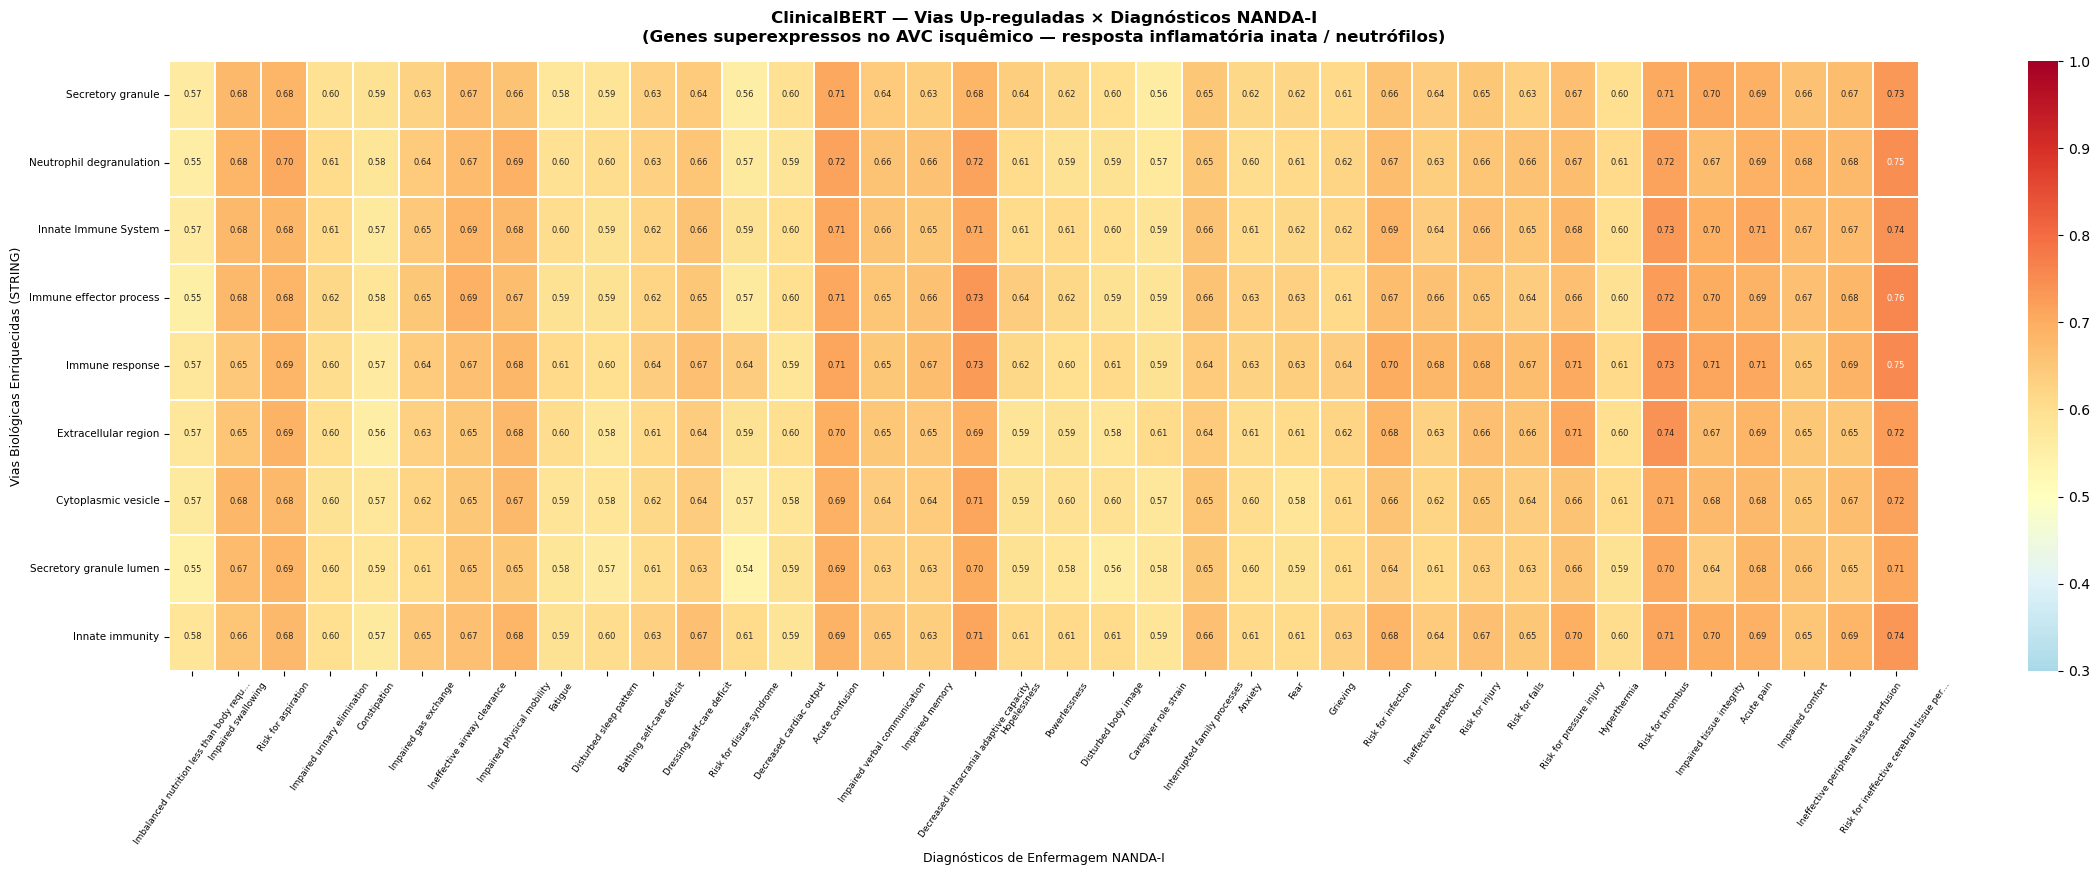

✓ Heatmap salvo: outputs/figures/heatmap_nanda_up.png


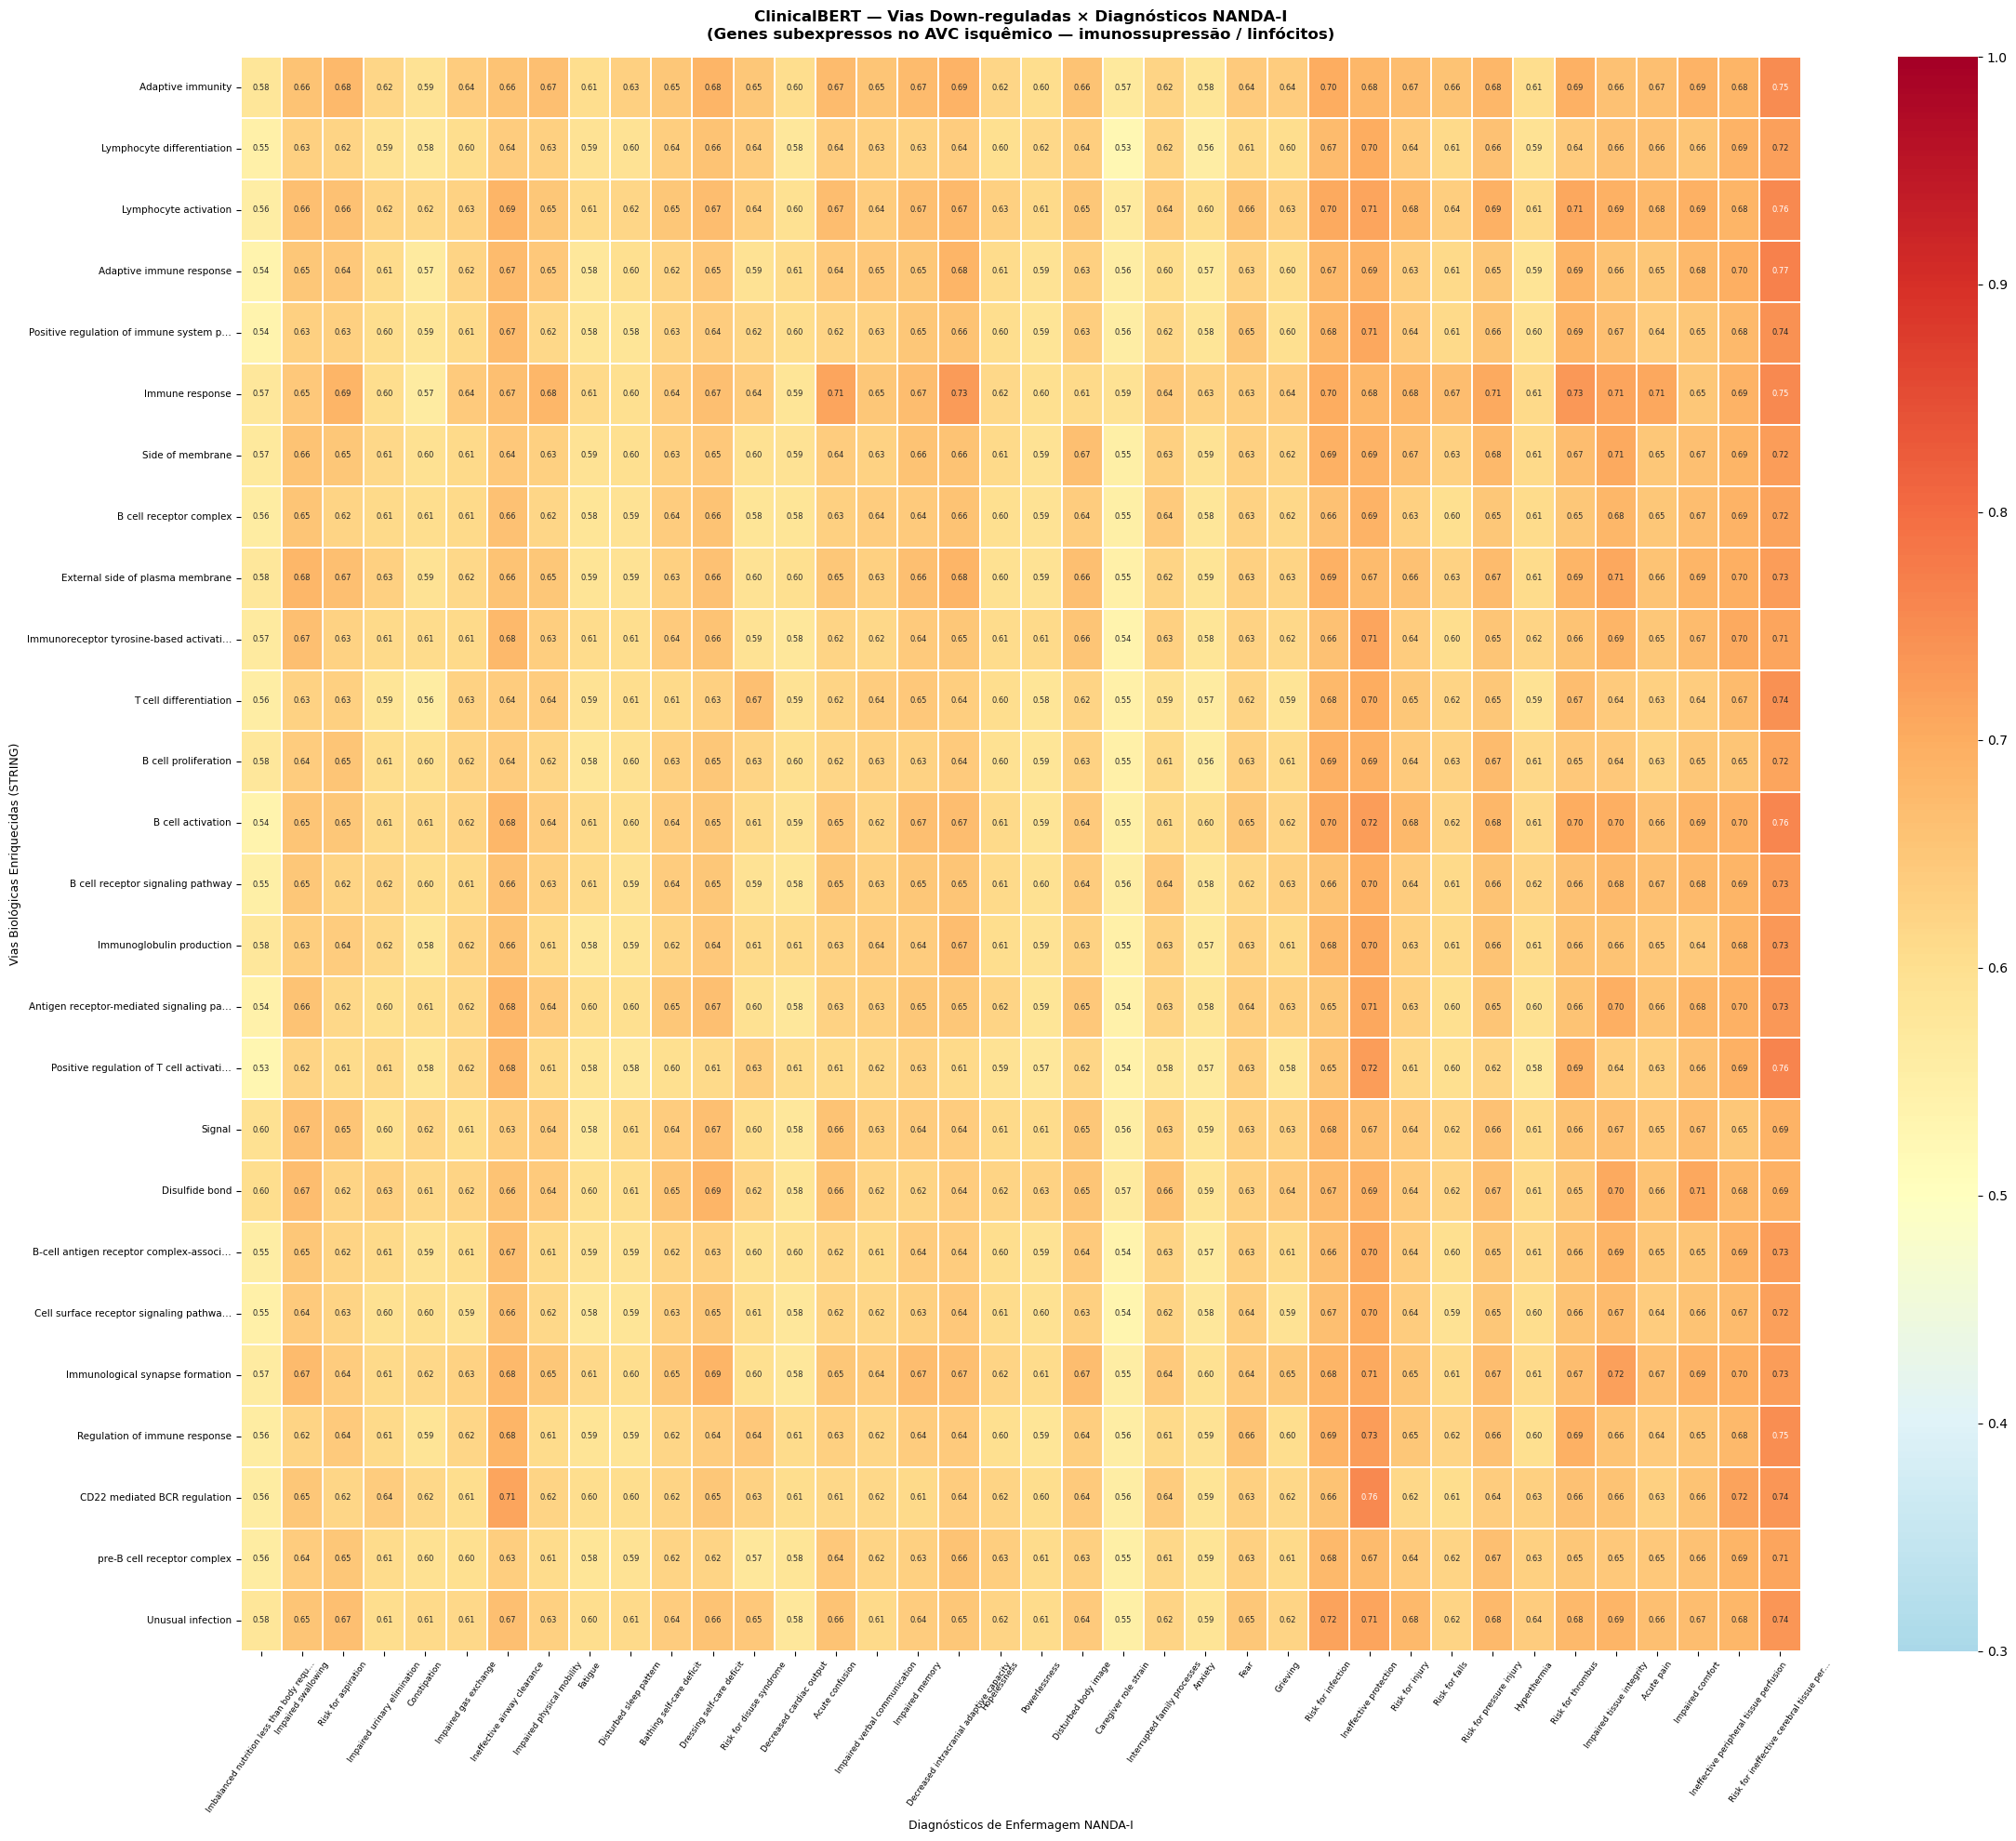

✓ Heatmap salvo: outputs/figures/heatmap_nanda_down.png


In [12]:
# -- Cell 8: Heatmaps -------------------------------------------------------
# One heatmap per regulatory direction. Color encodes cosine similarity
# (warm = high semantic alignment; cool = low). Labels are shortened for
# readability; full descriptions are preserved in the exported CSVs.

# ============================================================
# CÉLULA 8 — Heatmaps por direção regulatória
# ============================================================

def abreviar(texto, max_len=42):
    """Remove código NANDA e abrevia para exibição no heatmap."""
    texto_limpo = re.sub(r'\s*\(NANDA-I \d+\)', '', texto)
    texto_limpo = re.sub(r':.*', '', texto_limpo)  # mantém só o rótulo principal
    return texto_limpo[:max_len] + '…' if len(texto_limpo) > max_len else texto_limpo

def plotar_heatmap(df_matriz, titulo, nome_arquivo):
    df_heat = df_matriz.copy()
    df_heat.index   = [abreviar(v, 38) for v in df_heat.index]
    df_heat.columns = [abreviar(c, 40) for c in df_heat.columns]

    n_vias  = len(df_heat)
    n_nanda = len(df_heat.columns)
    altura  = max(5,  n_vias  * 0.65 + 3)
    largura = max(22, n_nanda * 0.52 + 4)

    fig, ax = plt.subplots(figsize=(largura, altura))
    sns.heatmap(
        df_heat,
        annot      = True,
        fmt        = '.2f',
        cmap       = 'RdYlBu_r',
        center     = 0.5,
        vmin       = 0.30,
        vmax       = 1.00,
        linewidths = 0.3,
        ax         = ax,
        annot_kws  = {'size': 6}
    )
    ax.set_title(titulo, fontsize=12, fontweight='bold', pad=14)
    ax.set_xlabel('Diagnósticos de Enfermagem NANDA-I', fontsize=9)
    ax.set_ylabel('Vias Biológicas Enriquecidas (STRING)', fontsize=9)
    ax.tick_params(axis='x', rotation=55, labelsize=6.5)
    ax.tick_params(axis='y', rotation=0,  labelsize=7.5)
    plt.tight_layout()
    plt.savefig(nome_arquivo, dpi=300, bbox_inches='tight')
    plt.show()
    print(f'✓ Heatmap salvo: {nome_arquivo}')

plotar_heatmap(
    df_matriz_up,
    'ClinicalBERT — Vias Up-reguladas × Diagnósticos NANDA-I\n'
    '(Genes superexpressos no AVC isquêmico — resposta inflamatória inata / neutrófilos)',
    'outputs/figures/heatmap_nanda_up.png'
)

plotar_heatmap(
    df_matriz_down,
    'ClinicalBERT — Vias Down-reguladas × Diagnósticos NANDA-I\n'
    '(Genes subexpressos no AVC isquêmico — imunossupressão / linfócitos)',
    'outputs/figures/heatmap_nanda_down.png'
)

In [13]:
# -- Cell 9: Export results -------------------------------------------------
# Three tiers of results are exported:
#   1. Valid pairs (similarity >= threshold) -- primary scientific output
#   2. Full top-5 rankings without threshold -- for calibration and audit
#   3. Raw similarity matrices -- for custom downstream analysis

import os
os.makedirs('outputs/figures', exist_ok=True)
os.makedirs('outputs/nanda',   exist_ok=True)

# ============================================================
# CÉLULA 9 — Exportar resultados do mapeamento NANDA-I
# ============================================================

# ── Adicionar via_expandida aos DataFrames de output ─────────
# Mapeia cada label de via para sua descrição expandida
# (mesma variável VIA_EXPANSAO da Célula 3b)
def enriquecer_com_expansao(df):
    """Adiciona coluna via_expandida ao DataFrame de pares."""
    df = df.copy()
    df.insert(
        df.columns.get_loc('via') + 1,  # coluna logo após 'via'
        'via_expandida',
        df['via'].map(VIA_EXPANSAO).fillna(df['via'])
    )
    return df

df_validos_up   = enriquecer_com_expansao(df_validos_up)
df_validos_down = enriquecer_com_expansao(df_validos_down)
df_validos_all  = enriquecer_com_expansao(df_validos_all)

# Verificação: nenhuma via deve ter expansão idêntica ao label
n_sem_expansao = (df_validos_all['via_expandida'] ==
                  df_validos_all['via']).sum()
if n_sem_expansao > 0:
    print(f"⚠️  {n_sem_expansao} via(s) sem expansão no mapa VIA_EXPANSAO:")
    sem = df_validos_all[df_validos_all['via_expandida'] ==
                         df_validos_all['via']]['via'].unique()
    for v in sem:
        print(f"   → '{v}'")
else:
    print(f"✓ Todas as vias têm descrição expandida no output")

# Mapeamentos com threshold aplicado (arquivo principal para análise)
df_validos_up.to_csv('outputs/nanda/nanda_mapping_up_threshold65.csv',    index=False, encoding='utf-8')
df_validos_down.to_csv('outputs/nanda/nanda_mapping_down_threshold65.csv', index=False, encoding='utf-8')
df_validos_all.to_csv('outputs/nanda/nanda_mapping_completo_threshold65.csv', index=False, encoding='utf-8')

# Rankings completos top-5 por via (sem threshold — para auditoria e ajuste)
df_rank_all.to_csv('outputs/nanda/nanda_ranking_top5_completo.csv', index=False, encoding='utf-8')

# Matrizes completas por direção
df_matriz_up.to_csv('outputs/nanda/matriz_similaridade_up_nanda.csv',   encoding='utf-8')
df_matriz_down.to_csv('outputs/nanda/matriz_similaridade_down_nanda.csv', encoding='utf-8')

# Compatibilidade retroativa com script.R (importação pela seção 2ª etapa)
df_rank_all.rename(columns={'diagnostico_nanda': 'condicao'}).to_csv(
    'outputs/nanda/top5_condicoes_por_via.csv', index=False, encoding='utf-8'
)
df_matriz_up.to_csv('outputs/nanda/matriz_similaridade_completa.csv', encoding='utf-8')

print('✓ Arquivos exportados:')
print(f'  → nanda_mapping_up_threshold65.csv         ({len(df_validos_up)} pares válidos Up)')
print(f'  → nanda_mapping_down_threshold65.csv       ({len(df_validos_down)} pares válidos Down)')
print(f'  → nanda_mapping_completo_threshold65.csv   ({len(df_validos_all)} pares válidos total)')
print(f'  → nanda_ranking_top5_completo.csv          ({len(df_rank_all)} pares totais)')
print(f'  → matriz_similaridade_up_nanda.csv         ({df_matriz_up.shape[0]}×{df_matriz_up.shape[1]})')
print(f'  → matriz_similaridade_down_nanda.csv       ({df_matriz_down.shape[0]}×{df_matriz_down.shape[1]})')
print(f'  → outputs/figures/heatmap_nanda_up.png')
print(f'  → outputs/figures/heatmap_nanda_down.png')
print()
print('PRÓXIMO PASSO: importe outputs/nanda/nanda_mapping_completo_threshold65.csv no R para visualização e validação.')

✓ Todas as vias têm descrição expandida no output
✓ Arquivos exportados:
  → nanda_mapping_up_threshold65.csv         (45 pares válidos Up)
  → nanda_mapping_down_threshold65.csv       (130 pares válidos Down)
  → nanda_mapping_completo_threshold65.csv   (175 pares válidos total)
  → nanda_ranking_top5_completo.csv          (175 pares totais)
  → matriz_similaridade_up_nanda.csv         (9×38)
  → matriz_similaridade_down_nanda.csv       (26×38)
  → outputs/figures/heatmap_nanda_up.png
  → outputs/figures/heatmap_nanda_down.png

PRÓXIMO PASSO: importe outputs/nanda/nanda_mapping_completo_threshold65.csv no R para visualização e validação.


In [ ]:
# -- Cell 10: Download outputs (Google Colab only) --------------------------
# Triggers automatic file downloads in Colab. In a local Jupyter environment
# the files are already saved to disk and this cell prints their location.

# ============================================================
# CÉLULA 10 — Download automático dos arquivos (Colab)
# ============================================================

try:
    from google.colab import files
    IN_COLAB = True
except ImportError:
    IN_COLAB = False
    print("⚠️  Ambiente não-Colab: downloads automáticos desativados.")
    print("   Arquivos disponíveis em:", os.getcwd())

if IN_COLAB:
    for fname in [
        'outputs/nanda/nanda_mapping_completo_threshold65.csv',
        'outputs/nanda/nanda_mapping_up_threshold65.csv',
        'outputs/nanda/nanda_mapping_down_threshold65.csv',
        'outputs/nanda/nanda_ranking_top5_completo.csv',
        'outputs/nanda/matriz_similaridade_up_nanda.csv',
        'outputs/nanda/matriz_similaridade_down_nanda.csv',
        'outputs/figures/heatmap_nanda_up.png',
        'outputs/figures/heatmap_nanda_down.png',
    ]:
        files.download(fname)
    print('✓ Downloads iniciados')

## Importing results in R

After the notebook finishes, import the NANDA-I mapping tables in R:

```r
library(dplyr)

# Primary output: valid pathway-diagnosis pairs (similarity >= 0.65)
nanda <- read.csv('outputs/nanda/nanda_mapping_completo_threshold65.csv',
                  fileEncoding = 'UTF-8')

# Filter by regulatory direction
nanda_up   <- nanda[nanda$regulacao == 'Up',   ]
nanda_down <- nanda[nanda$regulacao == 'Down', ]

# Full cosine similarity matrices for custom visualization
mat_up   <- read.csv('outputs/nanda/matriz_similaridade_up_nanda.csv',
                     row.names = 1, fileEncoding = 'UTF-8')
mat_down <- read.csv('outputs/nanda/matriz_similaridade_down_nanda.csv',
                     row.names = 1, fileEncoding = 'UTF-8')
```


In [14]:
# -- Cell 13: Verification --------------------------------------------------
# Run this cell after all others to confirm the pipeline completed correctly.
# All assertions must pass before sharing or publishing results.

# ============================================================
# CÉLULA 13 — Verificação final (C1–C7)
# C1-C5: pipeline usa fusão tardia de similaridade [CLS] + SBERT
# C6-C7: calibração de threshold (6c) e entropia por via (6d)
# ============================================================

# C1 — Vias carregadas + expansões disponíveis e válidas
assert isinstance(vias_up,   list) and len(vias_up)   > 0, \
    "C1: vias_up vazia"
assert isinstance(vias_down, list) and len(vias_down) > 0, \
    "C1: vias_down vazia"
assert all(len(v) < 120 for v in vias_up + vias_down), \
    "C1: possíveis títulos de artigos detectados (labels > 120 chars)"

# Verifica expansões
assert 'vias_up_expandidas' in dir() and \
       len(vias_up_expandidas) == len(vias_up), \
    "C1b: vias_up_expandidas ausente ou com tamanho divergente"
assert 'vias_down_expandidas' in dir() and \
       len(vias_down_expandidas) == len(vias_down), \
    "C1b: vias_down_expandidas ausente ou com tamanho divergente"
assert all(len(v) >= 50 for v in
           vias_up_expandidas + vias_down_expandidas), \
    "C1b: alguma via expandida tem menos de 50 chars (expansão incompleta)"
print("C1 ✓  labels OK | expansões OK "
      f"({len(vias_up_expandidas)} Up, "
      f"{len(vias_down_expandidas)} Down)")

# C2 — Diagnósticos NANDA-I presentes e com código
assert len(nanda_diagnosticos) >= 30, "C2: menos de 30 diagnósticos NANDA-I carregados"
assert all("NANDA-I" in d for d in nanda_diagnosticos), \
    "C2: algum diagnóstico sem código NANDA-I"

# C3 — Threshold aplicado corretamente
assert 'SIMILARITY_THRESHOLD' in dir(), "C3: SIMILARITY_THRESHOLD não definido"
if len(df_validos_all) > 0:
    assert df_validos_all['similaridade'].min() >= SIMILARITY_THRESHOLD, \
        f"C3: pares abaixo do threshold {SIMILARITY_THRESHOLD} encontrados"

# C4 — Arquivos exportados
arquivos_esperados = [
    'outputs/nanda/nanda_mapping_completo_threshold65.csv',
    'outputs/nanda/matriz_similaridade_up_nanda.csv',
    'outputs/nanda/matriz_similaridade_down_nanda.csv',
    'outputs/figures/heatmap_nanda_up.png',
    'outputs/figures/heatmap_nanda_down.png',
    'outputs/nanda/threshold_calibration.csv',    # novo
    'outputs/nanda/discriminacao_por_via.csv',    # novo
]
for arq in arquivos_esperados:
    assert os.path.exists(arq), f"C4: arquivo não encontrado: {arq}"


# C5 — Scores de similaridade dentro do intervalo esperado [-1, 1]
# Similarity scores must lie within the valid cosine range
assert sim_up.min()   >= -1.0 and sim_up.max()   <= 1.0, "C5: sim_up fora de [-1,1]"
assert sim_down.min() >= -1.0 and sim_down.max() <= 1.0, "C5: sim_down fora de [-1,1]"

print("✅ Todas as verificações C1–C5 passaram.")
print(f"   Vias Up         : {len(vias_up)}")
print(f"   Vias Down       : {len(vias_down)}")
print(f"   NANDA-I         : {len(nanda_diagnosticos)} diagnósticos")
print(f"   Threshold       : {SIMILARITY_THRESHOLD}")
print(f"   Pares válidos Up   : {len(df_validos_up)}")
print(f"   Pares válidos Down : {len(df_validos_down)}")
print(f"   Pares válidos total: {len(df_validos_all)}")

# C6 — Calibração de threshold executada e threshold atualizado
assert 'SIMILARITY_THRESHOLD' in dir(), \
    "C6: SIMILARITY_THRESHOLD não encontrado no escopo"
assert SIMILARITY_THRESHOLD >= 0.65, \
    f"C6: threshold {SIMILARITY_THRESHOLD:.4f} abaixo do mínimo 0.65"
assert os.path.exists('outputs/nanda/threshold_calibration.csv'), \
    "C6: arquivo threshold_calibration.csv não encontrado"

calib_df = pd.read_csv('outputs/nanda/threshold_calibration.csv')
assert len(calib_df) > 0, "C6: threshold_calibration.csv está vazio"

up_candidates = ['z_up', 'z_up_065', 'zscore_up']
down_candidates = ['z_down', 'z_down_065', 'zscore_down']

up_col = next((c for c in up_candidates if c in calib_df.columns), None)
down_col = next((c for c in down_candidates if c in calib_df.columns), None)

# fallback para nomes alternativos de colunas de z-score no arquivo de calibração
if up_col is None:
    up_col = next(
        (c for c in calib_df.columns if ("z" in c.lower() and "up" in c.lower())),
        None
    )
if down_col is None:
    down_col = next(
        (c for c in calib_df.columns if ("z" in c.lower() and "down" in c.lower())),
        None
    )

assert up_col is not None, \
    f"C6: coluna de z-score Up não encontrada. Colunas disponíveis: {list(calib_df.columns)}"
assert down_col is not None, \
    f"C6: coluna de z-score Down não encontrada. Colunas disponíveis: {list(calib_df.columns)}"

z_up_val   = float(calib_df[up_col].iloc[0])
z_down_val = float(calib_df[down_col].iloc[0])

assert z_up_val >= 1.5, \
    f"C6: threshold original z_up={z_up_val:.2f} < 1.5 " \
    f"(threshold estatisticamente fraco para direção Up)"
print(f"C6 ✓  threshold={SIMILARITY_THRESHOLD:.4f} "
      f"| z_up={z_up_val:.2f} | z_down={z_down_val:.2f}")

# C7 — Entropia: ao menos 50% das vias fora de alerta de colapso
assert os.path.exists('outputs/nanda/discriminacao_por_via.csv'), \
    "C7: arquivo discriminacao_por_via.csv não encontrado"

ent_df = pd.read_csv('outputs/nanda/discriminacao_por_via.csv')

# Normaliza coluna 'alerta_colapso' para booleano (robusto a bool/int/str)
alerta_raw = ent_df['alerta_colapso']
if alerta_raw.dtype == bool:
    alerta_bool = alerta_raw
elif pd.api.types.is_numeric_dtype(alerta_raw):
    alerta_bool = alerta_raw.astype(float) > 0
else:
    alerta_bool = (
        alerta_raw.astype(str).str.strip().str.lower()
        .map({
            '1': True, 'true': True, 't': True, 'yes': True, 'y': True, 'sim': True,
            '0': False, 'false': False, 'f': False, 'no': False, 'n': False, 'nao': False, 'não': False
        })
        .fillna(True)
    )

pct_ok = 1 - float(alerta_bool.mean())

if pct_ok < 0.50:
    status_c7 = "⚠️  (abaixo do mínimo)"
    print(
        f"C7 {status_c7}  {100*pct_ok:.1f}% das vias sem alerta de colapso. "
        "Recomendado: re-executar fine-tuning com lexical_hard_negatives."
    )
elif pct_ok < 0.70:
    status_c7 = "⚠️  (acima do mínimo, abaixo do ideal)"
    print(f"C7 {status_c7}  {100*pct_ok:.1f}% das vias sem alerta de colapso")
else:
    status_c7 = "✅"
    print(f"C7 {status_c7}  {100*pct_ok:.1f}% das vias sem alerta de colapso")

# C8 — Arquivo row_norm não deve existir (método incorreto)
row_norm_path = 'outputs/nanda/discriminacao_por_via_metodo_row_norm.csv'
if os.path.exists(row_norm_path):
    os.remove(row_norm_path)
    print("C8 ✓  discriminacao_por_via_metodo_row_norm.csv removido "
          "(método matematicamente incorreto)")
else:
    print("C8 ✓  arquivo row_norm ausente (correto)")

# Resumo final atualizado
print()
print("=" * 60)
print("  VERIFICAÇÃO FINAL — C1 a C7")
print("=" * 60)
print(f"  Vias Up               : {len(vias_up)}")
print(f"  Vias Down             : {len(vias_down)}")
print(f"  Diagnósticos NANDA-I  : {len(nanda_labels)}")
print(f"  Threshold calibrado   : {SIMILARITY_THRESHOLD:.4f}")
print(f"  Pares válidos Up      : {len(df_validos_up)}")
print(f"  Pares válidos Down    : {len(df_validos_down)}")
print(f"  Pares válidos total   : {len(df_validos_all)}")
print(f"  Vias sem colapso      : {100*pct_ok:.1f}%")
print(f"  Coluna via_expandida  : "
      f"{'presente' if 'via_expandida' in df_validos_all.columns else 'AUSENTE'}")
print(f"  Checkpoint meta       : "
      f"{'presente' if os.path.exists('outputs/sbert_nanda_finetuned/checkpoint_meta.json') else 'AUSENTE'}")
print("=" * 60)

C1 ✓  labels OK | expansões OK (9 Up, 26 Down)
✅ Todas as verificações C1–C5 passaram.
   Vias Up         : 9
   Vias Down       : 26
   NANDA-I         : 38 diagnósticos
   Threshold       : 0.65
   Pares válidos Up   : 45
   Pares válidos Down : 130
   Pares válidos total: 175
C6 ✓  threshold=0.6500 | z_up=18.35 | z_down=27.10
C7 ⚠️  (abaixo do mínimo)  0.0% das vias sem alerta de colapso. Recomendado: re-executar fine-tuning com lexical_hard_negatives.
C8 ✓  discriminacao_por_via_metodo_row_norm.csv removido (método matematicamente incorreto)

  VERIFICAÇÃO FINAL — C1 a C7
  Vias Up               : 9
  Vias Down             : 26
  Diagnósticos NANDA-I  : 38
  Threshold calibrado   : 0.6500
  Pares válidos Up      : 45
  Pares válidos Down    : 130
  Pares válidos total   : 175
  Vias sem colapso      : 0.0%
  Coluna via_expandida  : presente
  Checkpoint meta       : presente
